# Упражнение 5.12. Кольцевые гонки

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 5 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch05.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import trange

In [2]:
WALL, TRACK, START, FINISH = 0, 1, 2, 3

VMAX = 4         # обе компоненты скорости из {0, 1, 2, 3, 4}
NOISE_P = 0.1    

# 9 действий
ACTIONS = np.array([(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1)], dtype=int)
N_ACTIONS = 9

## Конструкторы трасс

Трассы заданы ASCII-литералами (`'#'` — wall, `'.'` — track, `'S'` — start, `'F'` — finish)

In [3]:
_CHAR_TO_CODE = {'#': WALL, '.': TRACK, 'S': START, 'F': FINISH}

def parse_track(rows):
    """ASCII -> numpy int8 массив. Все строки должны иметь одинаковую длину."""
    width = len(rows[0])
    assert all(len(r) == width for r in rows), "строки трассы разной длины"
    return np.array([[_CHAR_TO_CODE[c] for c in r] for r in rows], dtype=np.int8)


def make_track_a():
    """
    Левая трасса с рис. 5.5. Размер 32 × 17.
    """
    rows = [
        '###.............F',  # row 0
        '##..............F',  # 1
        '##..............F',  # 2
        '#...............F',  # 3
        '................F',  # 4
        '................F',  # 5
        '..........#######',  # 6
        '.........########',  # 7
        '.........########',  # 8
        '.........########',  # 9
        '.........########',  # 10
        '.........########',  # 11
        '.........########',  # 12
        '.........########',  # 13
        '#........########',  # 14
        '#........########',  # 15
        '#........########',  # 16
        '#........########',  # 17
        '#........########',  # 18
        '#........########',  # 19
        '#........########',  # 20
        '#........########',  # 21
        '##.......########',  # 22
        '##.......########',  # 23
        '##.......########',  # 24
        '##.......########',  # 25
        '##.......########',  # 26
        '##.......########',  # 27
        '##.......########',  # 28
        '###......########',  # 29
        '###......########',  # 30
        '###SSSSSS########',  # 31 — стартовая линия
    ]
    return parse_track(rows)


def make_track_b():
    """
    Правая трасса с рис. 5.5. Размер 30 × 32.
    """
    rows = [
        '################...............F',  # 0
        '#############..................F',  # 1
        '############...................F',  # 2
        '###########....................F',  # 3
        '###########....................F',  # 4
        '###########....................F',  # 5
        '###########....................F',  # 6
        '############...................F',  # 7
        '#############..................F',  # 8
        '##############................##',  # 9
        '##############.............#####',  # 10
        '##############............######',  # 11
        '##############..........########',  # 12
        '##############.........#########',  # 13
        '#############..........#########',  # 14
        '############...........#########',  # 15
        '###########............#########',  # 16
        '##########.............#########',  # 17
        '#########..............#########',  # 18
        '########...............#########',  # 19
        '#######................#########',  # 20
        '######.................#########',  # 21
        '#####..................#########',  # 22
        '####...................#########',  # 23
        '###....................#########',  # 24
        '##.....................#########',  # 25
        '#......................#########',  # 26
        '.......................#########',  # 27
        '.......................#########',  # 28
        'SSSSSSSSSSSSSSSSSSSSSSS#########',  # 29 — стартовая линия
    ]
    return parse_track(rows)

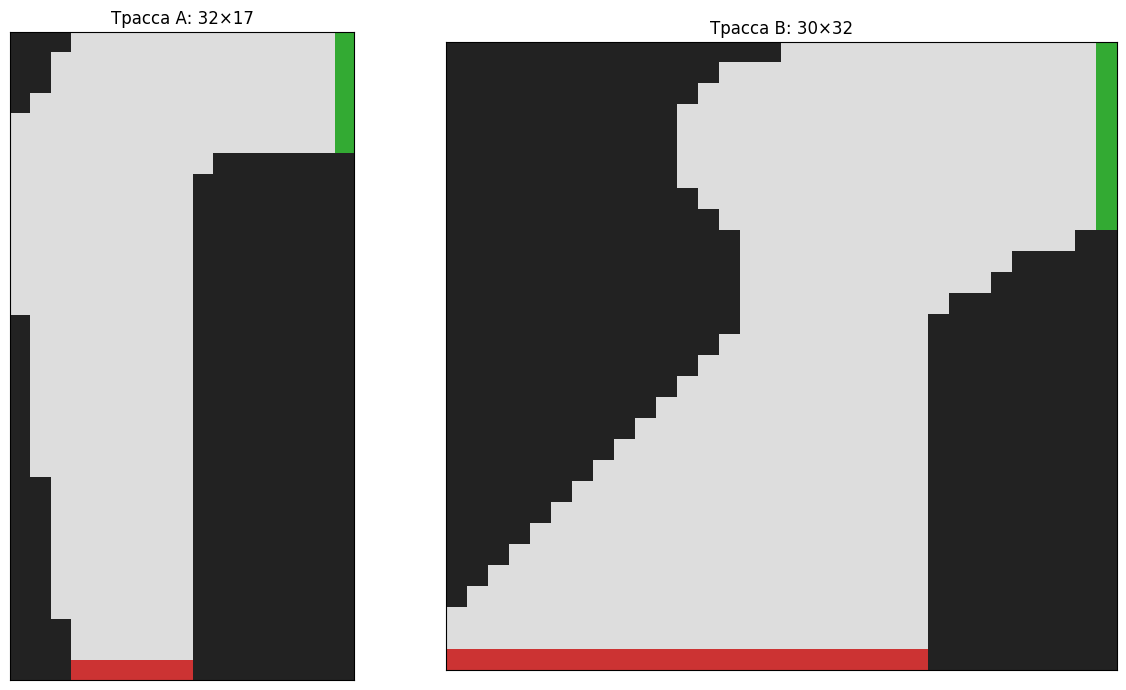

In [4]:
_TRACK_CMAP = ListedColormap(['#222222', '#dddddd', '#cc3333', '#33aa33'])  # WALL/TRACK/START/FINISH
_TRACK_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], _TRACK_CMAP.N)


def show_track(track, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(track.shape[1] * 0.25 + 1.5, track.shape[0] * 0.25 + 0.5))
    ax.imshow(track, cmap=_TRACK_CMAP, norm=_TRACK_NORM, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title)
    return ax


track_a = make_track_a()
track_b = make_track_b()

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
show_track(track_a, ax=axes[0], title=f'Трасса A: {track_a.shape[0]}×{track_a.shape[1]}')
show_track(track_b, ax=axes[1], title=f'Трасса B: {track_b.shape[0]}×{track_b.shape[1]}')
plt.tight_layout()
plt.show()

## Динамика среды

Состояние — `(row, col, vy, vx)`. Действие — индекс 0..8, отображающийся в пару `(Δvy, Δvx)`.

Шаг:
1. С вероятностью `NOISE_P = 0.1` приращения зануляются.
2. Скорость обновляется (невалидные действия отсекаются маской ещё на этапе выбора).
3. Траектория шага дискретизируется и проверяются все промежуточные клетки. Если первой пересечена клетка `FINISH` — эпизод закончен. Если `WALL` или вышли за границы — крушение, респаун на случайной клетке старта со скоростью (0, 0), эпизод **продолжается** (награды −1 продолжают начисляться).

Маска валидных действий зависит от текущей скорости и от того, стоит ли машина на клетке `START`.

In [5]:
# ───────────────── Маска валидных действий ─────────────────
def valid_action_mask(vy, vx, on_start):
    """
    Bool-массив длины 9: какие действия дают допустимое (vy', vx').
    Условия:
      * 0 ≤ vy', vx' ≤ VMAX
      * (vy', vx') = (0, 0) разрешено только на клетках START
    """
    mask = np.zeros(N_ACTIONS, dtype=bool)
    for i, (dy, dx) in enumerate(ACTIONS):
        ny, nx = vy + dy, vx + dx
        if not (0 <= ny <= VMAX and 0 <= nx <= VMAX):
            continue
        if ny == 0 and nx == 0 and not on_start:
            continue
        mask[i] = True
    return mask


# ───────────────── Дискретизация траектории шага ─────────────────
def trace_step(row, col, vy, vx, track):
    """
    Двигаем машину с (row, col) на (row - vy, col + vx) и проверяем все промежуточные клетки.
    Возвращаем (new_row, new_col, status), где status ∈ {'finish', 'crash', 'ok'}.
    """
    H, W = track.shape
    target_row = row - vy
    target_col = col + vx
    n_sub = max(abs(target_row - row), abs(target_col - col))
    if n_sub == 0:
        return row, col, 'ok'

    for k in range(1, n_sub + 1):
        t = k / n_sub
        rr = int(round(row + t * (target_row - row)))
        cc = int(round(col + t * (target_col - col)))
        if not (0 <= rr < H and 0 <= cc < W):
            return rr, cc, 'crash'
        cell = track[rr, cc]
        if cell == FINISH:
            return rr, cc, 'finish'
        if cell == WALL:
            return rr, cc, 'crash'
    return target_row, target_col, 'ok'


# ───────────────── Стартовый пул и сброс ─────────────────
def start_cells(track):
    return np.argwhere(track == START)


def reset(start_pool, rng):
    idx = rng.integers(len(start_pool))
    r, c = start_pool[idx]
    return int(r), int(c), 0, 0


# ───────────────── Шаг среды ─────────────────
def step(state, action_idx, track, start_pool, rng):
    """
    Шум → обновление скорости → trace_step → при crash respawn.
    Возвращает (next_state, reward, done).
    """
    row, col, vy, vx = state
    if rng.random() < NOISE_P:
        dy, dx = 0, 0
    else:
        dy, dx = ACTIONS[action_idx]

    new_vy = vy + dy
    new_vx = vx + dx

    new_row, new_col, status = trace_step(row, col, new_vy, new_vx, track)

    if status == 'finish':
        return (new_row, new_col, new_vy, new_vx), -1, True
    if status == 'crash':
        return reset(start_pool, rng), -1, False
    return (new_row, new_col, new_vy, new_vx), -1, False

## Алгоритм: first-visit MC control с инкрементальным Q

ε-мягкая политика выводится из Q налету через ε-greedy: с вероятностью ε действие выбирается равномерно среди **валидных**, иначе — `argmax_a Q(s, a)` тоже среди **валидных**. Это эквивалентно явной ε-soft форме из псевдокода.

In [6]:
# ───────────────── Поведенческая и жадная политики ─────────────────
def epsilon_greedy_action(Q, state, eps, track, rng):
    row, col, vy, vx = state
    on_start = bool(track[row, col] == START)
    mask = valid_action_mask(vy, vx, on_start)
    if rng.random() < eps:
        return int(rng.choice(np.flatnonzero(mask)))
    q = Q[row, col, vy, vx].copy()
    q[~mask] = -np.inf
    return int(np.argmax(q))


def greedy_action(Q, state, track):
    row, col, vy, vx = state
    on_start = bool(track[row, col] == START)
    mask = valid_action_mask(vy, vx, on_start)
    q = Q[row, col, vy, vx].copy()
    q[~mask] = -np.inf
    return int(np.argmax(q))

In [7]:
# ───────────────── Генерация эпизода ─────────────────
def generate_episode(track, start_pool, Q, eps, rng, max_steps=10_000):
    state = reset(start_pool, rng)
    trajectory = []
    for _ in range(max_steps):
        action = epsilon_greedy_action(Q, state, eps, track, rng)
        next_state, reward, done = step(state, action, track, start_pool, rng)
        trajectory.append((state, action, reward))
        state = next_state
        if done:
            break
    return trajectory


# ───────────────── MC-контроль с инкрементальным Q ─────────────────
def mc_control(track, n_episodes, eps=0.1, gamma=1.0, max_steps=10_000, seed=0, log_every=2000):
    H, W = track.shape
    Q = np.zeros((H, W, VMAX + 1, VMAX + 1, N_ACTIONS), dtype=np.float64)
    N = np.zeros_like(Q, dtype=np.int64)
    rng = np.random.default_rng(seed)
    start_pool = start_cells(track)

    history = []          # [(номер эпизода, средняя длина в окне)]
    window = []           # длины эпизодов в текущем окне

    for ep in trange(n_episodes, desc='episodes'):
        traj = generate_episode(track, start_pool, Q, eps, rng, max_steps)
        window.append(len(traj))

        # First-visit: индекс первого появления каждой пары (s, a) в эпизоде
        first_t = {}
        for t, (state, action, _) in enumerate(traj):
            key = (state[0], state[1], state[2], state[3], action)
            if key not in first_t:
                first_t[key] = t

        # Обратный проход: считаем G и обновляем Q только при t == first_t[key]
        G = 0.0
        for t in range(len(traj) - 1, -1, -1):
            state, action, reward = traj[t]
            G = gamma * G + reward
            key = (state[0], state[1], state[2], state[3], action)
            if first_t[key] == t:
                r, c, vy, vx = state
                N[r, c, vy, vx, action] += 1
                Q[r, c, vy, vx, action] += (G - Q[r, c, vy, vx, action]) / N[r, c, vy, vx, action]

        if (ep + 1) % log_every == 0:
            history.append((ep + 1, float(np.mean(window))))
            window = []

    return Q, N, history

In [8]:
# ───────────────── Прогон жадной политики и визуализация ─────────────────
def rollout_greedy(track, start_pool, Q, start_cell=None, with_noise=False, rng=None, max_steps=1000):
    """
    Прогоняет жадную политику. При crash (без шума) или штатно через step (с шумом)
    делается respawn — это даёт полный путь до финиша даже если жадная политика
    иногда вылетает в стену. Между сегментами вставляется None — отметка для рисовалки.
    Возвращает список состояний с None в местах respawn.
    """
    if rng is None:
        rng = np.random.default_rng()
    if start_cell is None:
        start_cell = tuple(start_pool[rng.integers(len(start_pool))])
    state = (int(start_cell[0]), int(start_cell[1]), 0, 0)
    states = [state]
    for _ in range(max_steps):
        action = greedy_action(Q, state, track)
        if with_noise:
            state, _, done = step(state, action, track, start_pool, rng)
            states.append(state)
            if done:
                break
        else:
            row, col, vy, vx = state
            dy, dx = ACTIONS[action]
            new_vy = max(0, min(VMAX, vy + dy))
            new_vx = max(0, min(VMAX, vx + dx))
            new_row, new_col, status = trace_step(row, col, new_vy, new_vx, track)
            if status == 'finish':
                states.append((new_row, new_col, new_vy, new_vx))
                break
            if status == 'crash':
                idx = rng.integers(len(start_pool))
                state = (int(start_pool[idx][0]), int(start_pool[idx][1]), 0, 0)
                states.append(None)         # разрыв линии при отрисовке
                states.append(state)
            else:
                state = (new_row, new_col, new_vy, new_vx)
                states.append(state)
    return states


def plot_trajectories(track, trajectories, ax=None, title=None):
    """Рисует траектории. None в списке состояний разрывает линию (это respawn)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(track.shape[1] * 0.3 + 1.5, track.shape[0] * 0.3 + 0.5))
    show_track(track, ax=ax, title=title)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(trajectories), 1)))
    for traj, color in zip(trajectories, colors):
        # NaN на месте None заставит matplotlib разорвать линию
        rs = [s[0] if s is not None else np.nan for s in traj]
        cs = [s[1] if s is not None else np.nan for s in traj]
        ax.plot(cs, rs, '-o', color=color, markersize=3, linewidth=1.5, alpha=0.85)
    return ax


def plot_learning_curve(history, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))
    eps_axis, lens = zip(*history)
    ax.plot(eps_axis, lens, '-o', linewidth=2, markersize=4)
    ax.set_xlabel('Эпизод')
    ax.set_ylabel('Средняя длина эпизода в окне')
    ax.grid(True)
    if title is not None:
        ax.set_title(title)
    return ax

## Обучение на трассе A

In [12]:
N_EPISODES_A = 1_000_000
Q_a, N_a, hist_a = mc_control(track_a, N_EPISODES_A, eps=0.1, gamma=1.0, seed=0)

episodes:   0%|          | 0/1000000 [00:00<?, ?it/s]

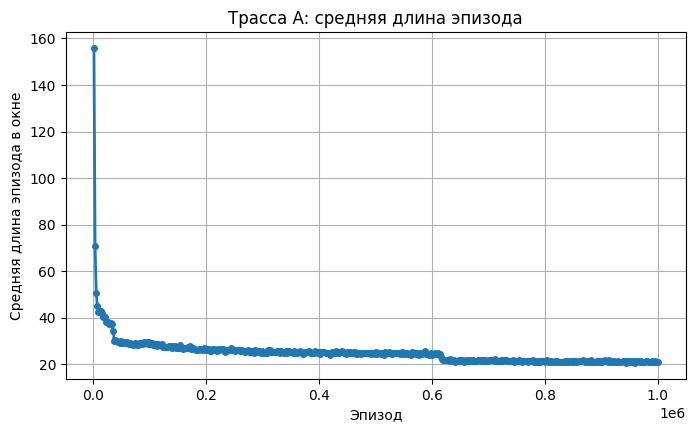

In [13]:
plot_learning_curve(hist_a, title='Трасса A: средняя длина эпизода')
plt.show()

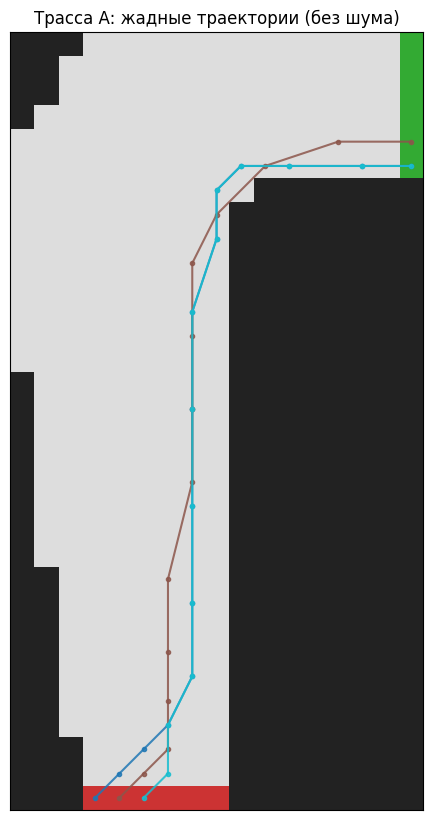

In [15]:
# Жадные траектории из каждой стартовой клетки (без шума)
rng_show = np.random.default_rng(42)
start_pool_a = start_cells(track_a)[:3]
trajs_a = [
    rollout_greedy(track_a, start_pool_a, Q_a, start_cell=tuple(sc), with_noise=False, rng=rng_show)
    for sc in start_pool_a
]
plot_trajectories(track_a, trajs_a, title='Трасса A: жадные траектории (без шума)')
plt.show()

## Обучение на трассе B

In [16]:
N_EPISODES_B = 1_000_000
Q_b, N_b, hist_b = mc_control(track_b, N_EPISODES_B, eps=0.1, gamma=1.0, seed=0)

episodes:   0%|          | 0/1000000 [00:00<?, ?it/s]

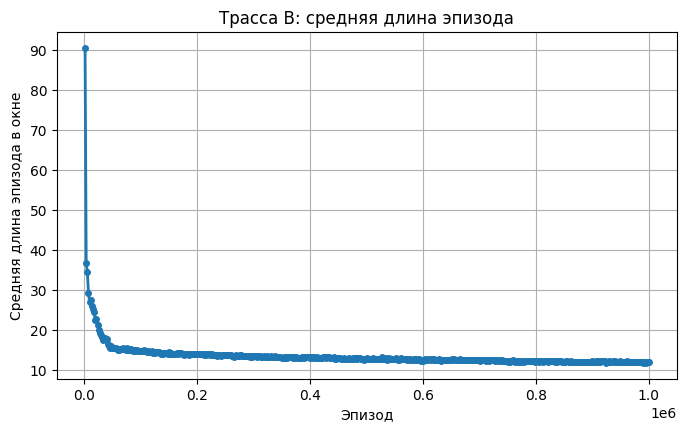

In [17]:
plot_learning_curve(hist_b, title='Трасса B: средняя длина эпизода')
plt.show()

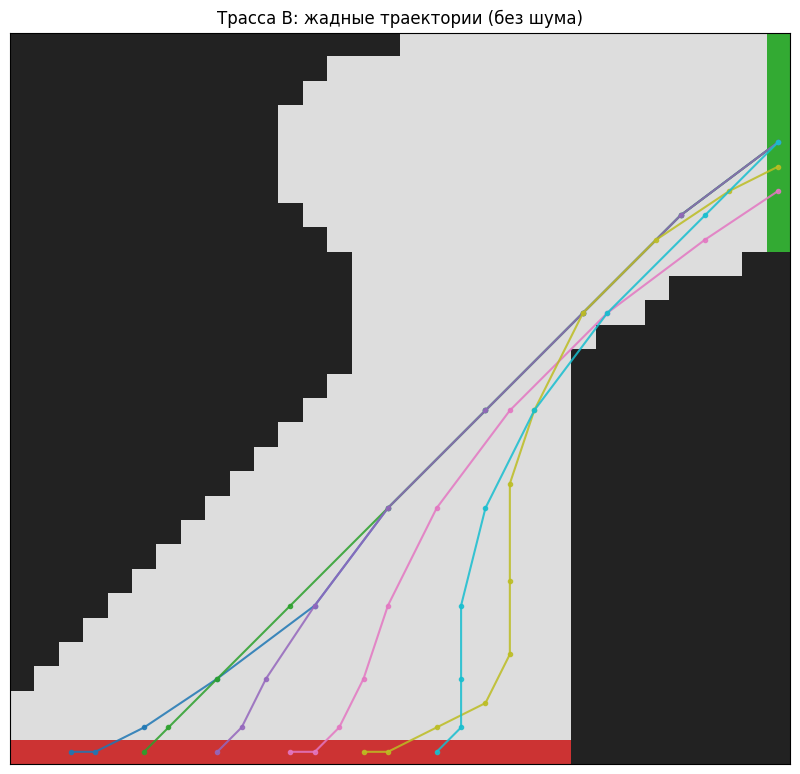

In [20]:
rng_show = np.random.default_rng(42)
start_pool_b = start_cells(track_b)[2:20]
sample_starts = start_pool_b[::3]
trajs_b = [
    rollout_greedy(track_b, start_pool_b, Q_b, start_cell=tuple(sc), with_noise=False, rng=rng_show)
    for sc in sample_starts
]
plot_trajectories(track_b, trajs_b, title='Трасса B: жадные траектории (без шума)')
plt.show()